In [1]:
#remotes::install_github("jinworks/CellChat@88c2e13")

suppressPackageStartupMessages({
    library(CellChat)
    library(zellkonverter)
    library(SingleCellExperiment())
    library(ComplexHeatmap)
})



In [2]:
library(tidyr)
library(tibble)


Attaching package: ‘tidyr’


The following object is masked from ‘package:S4Vectors’:

    expand


The following object is masked from ‘package:igraph’:

    crossing



Attaching package: ‘tibble’


The following object is masked from ‘package:igraph’:

    as_data_frame




In [3]:
dist_out_dir <- "/home/workspace/spatial_mouse_lung_outputs/downstream_analysis/distance"
dist_out_dir_cellchat <- "/home/workspace/spatial_mouse_lung_outputs/downstream_analysis/distance/cellchat_tls-category"
plot_out_dir <- file.path(dist_out_dir_cellchat, "plots")

## Load cellchat results

In [4]:
path =  file.path(dist_out_dir_cellchat, "cellchat_HDM_day3_trim_0.1_intrange_50_contact_10_popsize_FALSE.rds")
cellchat = readRDS(path)


## Plotting palettes


In [5]:
celltype_palette_mapped <- c('AT1'= '#ffff00',
 'AT2'= '#1ce6ff',
 'Club'= '#ff34ff',
 'Ciliated'= '#ff4a46',
 'SMC'= '#008941',
 'Col13a1+ fibroblast'= '#006fa6',
 'Col14a1+ fibroblast'= '#a30059',
 'Myofibroblast'= '#ffdbe5',
 'Pericyte 1'= '#7a4900',
 'Pericyte 2'= '#0000a6',
 'Mesothelial'= '#63ffac',
 'Cap'= '#b79762',
 'Cap-a'= '#004d43',
 'Art'= '#8fb0ff',
 'Vein'= '#997d87',
 'Lymph'= '#5a0007',
 'Mono'= '#809693',
 'Int Mf'= '#6a3a4c',
 'Alv Mf'= '#1b4400',
 'Neut'= '#4fc601',
 'cDC1'= '#3b5dff',
 'Ccr7- cDC2'= '#4a3b53',
 'Ccr7+ cDC2'= '#ff2f80',
 'B cell'= '#61615a',
 'Plasmablast'= '#ba0900',
 'NK cell'= '#6b7900',
 'gd T cell'= '#00c2a0',
 'ILC2'= '#ffaa92',
 'CD8 naive'= '#ff90c9',
 'CD8 act'= '#b903aa',
 'CD4 naive'= '#d16100',
 'CD4 act (tls core)'='#006400', 
                             'CD4 act (tls outer)'='#98FB98', 
                             'CD4 act (tls surround)'='#BDB76B'                             
)

## Adjust cell label order for plotting

In [6]:
# First adjust the cell label order
label_df <- read.csv("/home/workspace/spatial_tls_manuscript/inputs/20250519_mouse_lung_label_mapping_ordered.csv")

# Get the current labels in the CellChat object
cellchat_labels <- unique(cellchat@idents)

# Keep only labels that are in the cellchat object
ordered_labels <- label_df$label_fine[label_df$label_fine %in% cellchat_labels]

# Optional: Append custom labels (if needed)
extra_labels <- c('CD4 act (tls surround)','CD4 act (tls outer)', 'CD4 act (tls core)')
cell_order <- c(as.character(ordered_labels), extra_labels)
cell_order <- rev(cell_order)

# Update the CellChat object with new label order
cellchat@meta$labels <- factor(cellchat@idents, levels = cell_order)
cellchat <- updateClusterLabels(cellchat, new.order = cell_order)

Only reorder cell groups but do not rename cell groups!

Reorder cell groups! 



The cell group order before reordering is  AT1 AT2 Alv Mf Art B cell CD4 act (tls core) CD4 act (tls outer) CD4 act (tls surround) CD4 naive CD8 act CD8 naive Cap Cap-a Ccr7+ cDC2 Ccr7- cDC2 Ciliated Club Col13a1+ fibroblast Col14a1+ fibroblast ILC2 Int Mf Lymph Mesothelial Mono Myofibroblast NK cell Neut Pericyte 1 Pericyte 2 Plasmablast SMC Vein cDC1 gd T cell 
The cell group order after reordering is  CD4 act (tls core) CD4 act (tls outer) CD4 act (tls surround) CD4 naive CD8 act CD8 naive ILC2 gd T cell NK cell Plasmablast B cell Ccr7+ cDC2 Ccr7- cDC2 cDC1 Neut Alv Mf Int Mf Mono Lymph Vein Art Cap-a Cap Mesothelial Pericyte 2 Pericyte 1 Myofibroblast Col14a1+ fibroblast Col13a1+ fibroblast SMC Ciliated Club AT2 AT1 


We now re-run computeCommunProbPathway`,`aggregateNet`, and `netAnalysis_computeCentrality`...



In [7]:
# reorder palette
celltype_palette_mapped <- celltype_palette_mapped[cell_order]
celltype_palette_mapped

CD4 act (tls core)    CD4 act (tls outer) CD4 act (tls surround) 
             "#006400"              "#98FB98"              "#BDB76B" 
             CD4 naive                CD8 act              CD8 naive 
             "#d16100"              "#b903aa"              "#ff90c9" 
                  ILC2              gd T cell                NK cell 
             "#ffaa92"              "#00c2a0"              "#6b7900" 
           Plasmablast                 B cell             Ccr7+ cDC2 
             "#ba0900"              "#61615a"              "#ff2f80" 
            Ccr7- cDC2                   cDC1                   Neut 
             "#4a3b53"              "#3b5dff"              "#4fc601" 
                Alv Mf                 Int Mf                   Mono 
             "#1b4400"              "#6a3a4c"              "#809693" 
                 Lymph                   Vein                    Art 
             "#5a0007"              "#997d87"              "#8fb0ff" 
                 Cap-a                    Cap            Mesothelial 
             "#004d43"              "#b79762"              "#63ffac" 
            Pericyte 2             Pericyte 1          Myofibroblast 
             "#0000a6"              "#7a4900"              "#ffdbe5" 
   Col14a1+ fibroblast    Col13a1+ fibroblast                    SMC 
             "#a30059"              "#006fa6"              "#008941" 
              Ciliated                   Club                    AT2 
             "#ff4a46"              "#ff34ff"              "#1ce6ff" 
                   AT1 
             "#ffff00"

### Run netAnalysis_computeCentrality

In [8]:
cellchat <- netAnalysis_computeCentrality(cellchat, slot.name = "netP")

### Subset communication

In [9]:
# targets.use = c('CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)')
# cellchat_cd4 <- subsetCommunication(cellchat, targets.use = targets.use)

In [10]:
# cellchat_cd4

## Compare main signaling plots

In [107]:
path10 =  file.path(dist_out_dir_cellchat, "cellchat_HDM_day3_trim_0.1_intrange_50_contact_10_popsize_FALSE.rds")
path1 =  file.path(dist_out_dir_cellchat, "cellchat_HDM_day3_trim_0.1_intrange_50_contact_1000_popsize_FALSE.rds")

cellchat10 = readRDS(path10)
cellchat1 = readRDS(path1)

In [108]:
# First adjust the cell label order
label_df <- read.csv("/home/workspace/spatial_tls_manuscript/inputs/20250519_mouse_lung_label_mapping_ordered.csv")

# Get the current labels in the CellChat object
cellchat_labels <- unique(cellchat1@idents)

# Keep only labels that are in the cellchat object
ordered_labels <- label_df$label_fine[label_df$label_fine %in% cellchat_labels]

# Optional: Append custom labels (if needed)
extra_labels <- c('CD4 act (tls surround)','CD4 act (tls outer)', 'CD4 act (tls core)')
cell_order <- c(as.character(ordered_labels), extra_labels)
cell_order <- rev(cell_order)

# Update the CellChat object with new label order
cellchat1@meta$labels <- factor(cellchat1@idents, levels = cell_order)
cellchat1 <- updateClusterLabels(cellchat1, new.order = cell_order)

Only reorder cell groups but do not rename cell groups!

Reorder cell groups! 



The cell group order before reordering is  AT1 AT2 Alv Mf Art B cell CD4 act (tls core) CD4 act (tls outer) CD4 act (tls surround) CD4 naive CD8 act CD8 naive Cap Cap-a Ccr7+ cDC2 Ccr7- cDC2 Ciliated Club Col13a1+ fibroblast Col14a1+ fibroblast ILC2 Int Mf Lymph Mesothelial Mono Myofibroblast NK cell Neut Pericyte 1 Pericyte 2 Plasmablast SMC Vein cDC1 gd T cell 
The cell group order after reordering is  CD4 act (tls core) CD4 act (tls outer) CD4 act (tls surround) CD4 naive CD8 act CD8 naive ILC2 gd T cell NK cell Plasmablast B cell Ccr7+ cDC2 Ccr7- cDC2 cDC1 Neut Alv Mf Int Mf Mono Lymph Vein Art Cap-a Cap Mesothelial Pericyte 2 Pericyte 1 Myofibroblast Col14a1+ fibroblast Col13a1+ fibroblast SMC Ciliated Club AT2 AT1 


We now re-run computeCommunProbPathway`,`aggregateNet`, and `netAnalysis_computeCentrality`...



In [109]:
# First adjust the cell label order
label_df <- read.csv("/home/workspace/spatial_tls_manuscript/inputs/20250519_mouse_lung_label_mapping_ordered.csv")

# Get the current labels in the CellChat object
cellchat_labels <- unique(cellchat10@idents)

# Keep only labels that are in the cellchat object
ordered_labels <- label_df$label_fine[label_df$label_fine %in% cellchat_labels]

# Optional: Append custom labels (if needed)
extra_labels <- c('CD4 act (tls surround)','CD4 act (tls outer)', 'CD4 act (tls core)')
cell_order <- c(as.character(ordered_labels), extra_labels)
cell_order <- rev(cell_order)

# Update the CellChat object with new label order
cellchat10@meta$labels <- factor(cellchat10@idents, levels = cell_order)
cellchat10 <- updateClusterLabels(cellchat10, new.order = cell_order)

Only reorder cell groups but do not rename cell groups!

Reorder cell groups! 



The cell group order before reordering is  AT1 AT2 Alv Mf Art B cell CD4 act (tls core) CD4 act (tls outer) CD4 act (tls surround) CD4 naive CD8 act CD8 naive Cap Cap-a Ccr7+ cDC2 Ccr7- cDC2 Ciliated Club Col13a1+ fibroblast Col14a1+ fibroblast ILC2 Int Mf Lymph Mesothelial Mono Myofibroblast NK cell Neut Pericyte 1 Pericyte 2 Plasmablast SMC Vein cDC1 gd T cell 
The cell group order after reordering is  CD4 act (tls core) CD4 act (tls outer) CD4 act (tls surround) CD4 naive CD8 act CD8 naive ILC2 gd T cell NK cell Plasmablast B cell Ccr7+ cDC2 Ccr7- cDC2 cDC1 Neut Alv Mf Int Mf Mono Lymph Vein Art Cap-a Cap Mesothelial Pericyte 2 Pericyte 1 Myofibroblast Col14a1+ fibroblast Col13a1+ fibroblast SMC Ciliated Club AT2 AT1 


We now re-run computeCommunProbPathway`,`aggregateNet`, and `netAnalysis_computeCentrality`...



In [110]:
cellchat10 <- netAnalysis_computeCentrality(cellchat10, slot.name = "netP")
cellchat1 <- netAnalysis_computeCentrality(cellchat1, slot.name = "netP")

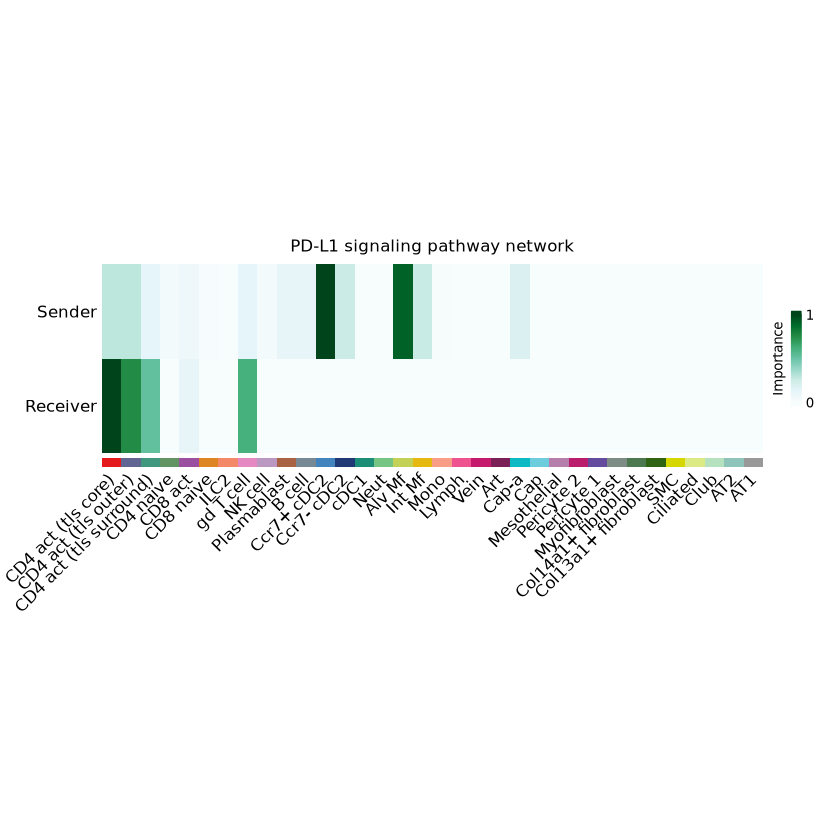

In [111]:
pathways.show = c("PD-L1")
netAnalysis_signalingRole_network(cellchat10, signaling = pathways.show,
                                  measure = c("outdeg", "indeg"), measure.name = c("Sender", "Receiver"), # exclude , "Mediator", "Influencer"
                                  width = 14, height = 4, font.size = 10)

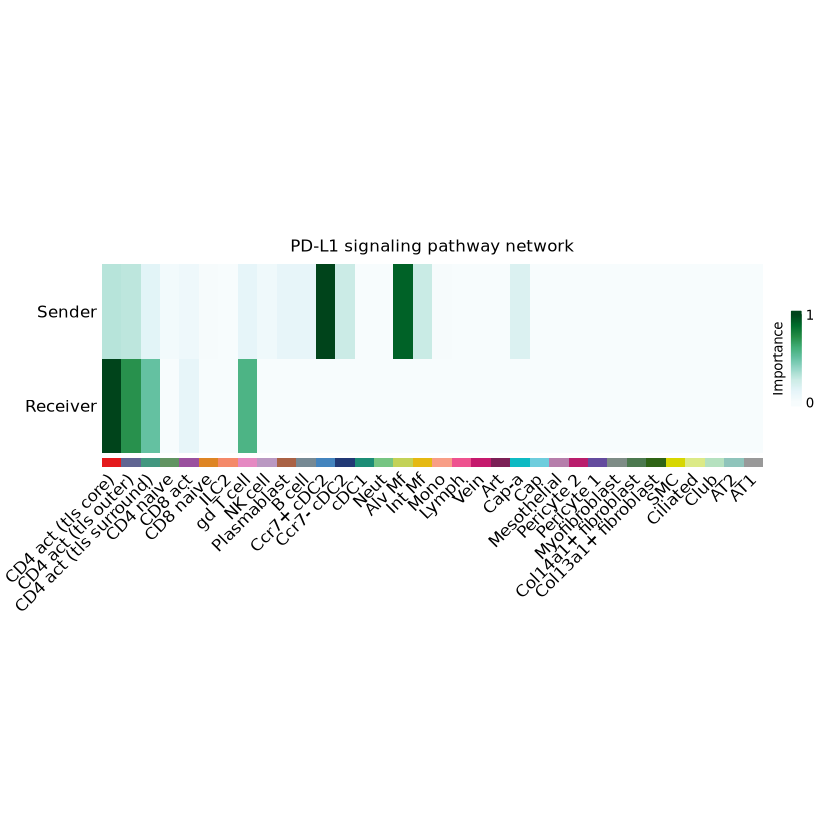

In [112]:
pathways.show = c("PD-L1")
netAnalysis_signalingRole_network(cellchat1, signaling = pathways.show,
                                  measure = c("outdeg", "indeg"), measure.name = c("Sender", "Receiver"), # exclude , "Mediator", "Influencer"
                                  width = 14, height = 4, font.size = 10)

In [113]:
thresh = 0.05
df.net10 <- subsetCommunication(cellchat10,
                            slot.name = "net",
                            # sources.use = sources.use,
                            # targets.use = targets.use,
                            signaling = signaling,
                            thresh = thresh)

df.net1 <- subsetCommunication(cellchat1,
                            slot.name = "net",
                            # sources.use = sources.use,
                            # targets.use = targets.use,
                            signaling = signaling,
                            thresh = thresh)

In [124]:
head(df.net10 %>% filter(source=='Ccr7+ cDC2', target %in% c('CD4 act (tls core)','CD4 act (tls outer)','CD4 act (tls surround)'),
                         annotation=='Cell-Cell Contact'))
                         # ligand=="Pdcd1lg2"))

,source,target,ligand,receptor,prob,pval,interaction_name,interaction_name_2,pathway_name,annotation,evidence
,<fct>,<fct>,<chr>,<chr>,<dbl>,<dbl>,<fct>,<chr>,<chr>,<chr>,<chr>
1,Ccr7+ cDC2,CD4 act (tls core),Cd80,Cd274,0.0002859386,0,CD80_CD274,Cd80 - Cd274,CD80,Cell-Cell Contact,PMID: 17629517; PMID: 18585785
2,Ccr7+ cDC2,CD4 act (tls outer),Cd80,Cd274,0.0003324608,0,CD80_CD274,Cd80 - Cd274,CD80,Cell-Cell Contact,PMID: 17629517; PMID: 18585785
3,Ccr7+ cDC2,CD4 act (tls surround),Cd80,Cd274,0.0001756709,0,CD80_CD274,Cd80 - Cd274,CD80,Cell-Cell Contact,PMID: 17629517; PMID: 18585785
4,Ccr7+ cDC2,CD4 act (tls core),Cd80,Cd28,0.0024138457,0,CD80_CD28,Cd80 - Cd28,CD80,Cell-Cell Contact,PMID: 23954143
5,Ccr7+ cDC2,CD4 act (tls outer),Cd80,Cd28,0.0022570894,0,CD80_CD28,Cd80 - Cd28,CD80,Cell-Cell Contact,PMID: 23954143
6,Ccr7+ cDC2,CD4 act (tls surround),Cd80,Cd28,0.0015989131,0,CD80_CD28,Cd80 - Cd28,CD80,Cell-Cell Contact,PMID: 23954143


In [125]:
head(df.net1 %>% filter(source=='Ccr7+ cDC2', target %in% c('CD4 act (tls core)','CD4 act (tls outer)','CD4 act (tls surround)'),
                         annotation=='Cell-Cell Contact'))
                         # ligand=="Pdcd1lg2"))

,source,target,ligand,receptor,prob,pval,interaction_name,interaction_name_2,pathway_name,annotation,evidence
,<fct>,<fct>,<chr>,<chr>,<dbl>,<dbl>,<fct>,<chr>,<chr>,<chr>,<chr>
1,Ccr7+ cDC2,CD4 act (tls core),Cd80,Cd274,0.0002859386,0,CD80_CD274,Cd80 - Cd274,CD80,Cell-Cell Contact,PMID: 17629517; PMID: 18585785
2,Ccr7+ cDC2,CD4 act (tls outer),Cd80,Cd274,0.0003324608,0,CD80_CD274,Cd80 - Cd274,CD80,Cell-Cell Contact,PMID: 17629517; PMID: 18585785
3,Ccr7+ cDC2,CD4 act (tls surround),Cd80,Cd274,0.0001756709,0,CD80_CD274,Cd80 - Cd274,CD80,Cell-Cell Contact,PMID: 17629517; PMID: 18585785
4,Ccr7+ cDC2,CD4 act (tls core),Cd80,Cd28,0.0024138457,0,CD80_CD28,Cd80 - Cd28,CD80,Cell-Cell Contact,PMID: 23954143
5,Ccr7+ cDC2,CD4 act (tls outer),Cd80,Cd28,0.0022570894,0,CD80_CD28,Cd80 - Cd28,CD80,Cell-Cell Contact,PMID: 23954143
6,Ccr7+ cDC2,CD4 act (tls surround),Cd80,Cd28,0.0015989131,0,CD80_CD28,Cd80 - Cd28,CD80,Cell-Cell Contact,PMID: 23954143


In [116]:
print(dim(df.net10))
print(dim(df.net1))

[1] 23969    11
[1] 24841    11


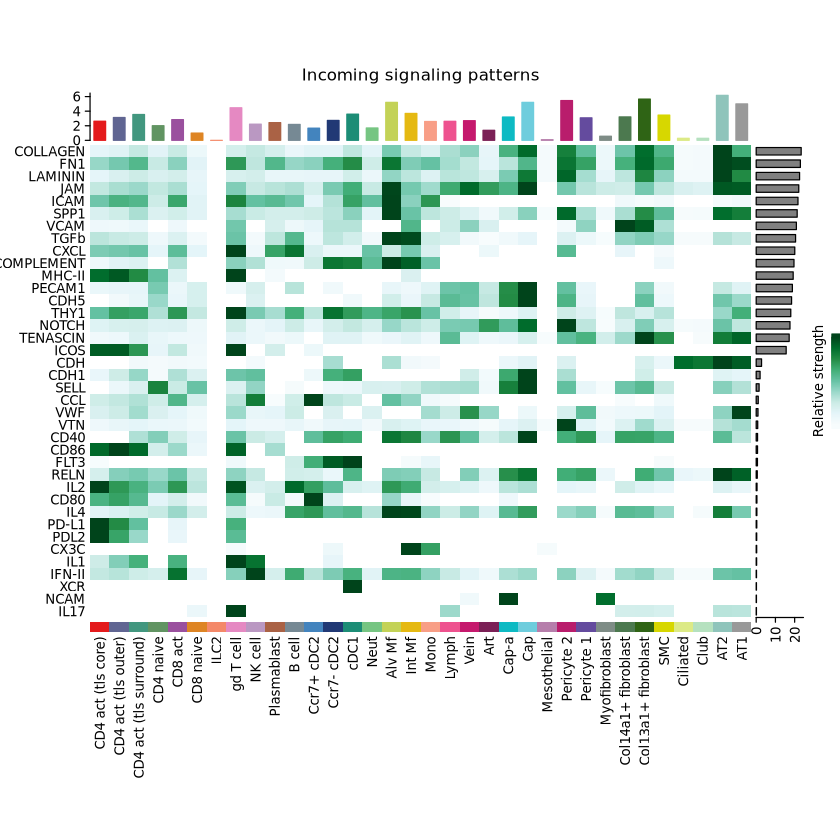

In [117]:
netAnalysis_signalingRole_heatmap(cellchat10, pattern = "incoming", width=14, height = 10)

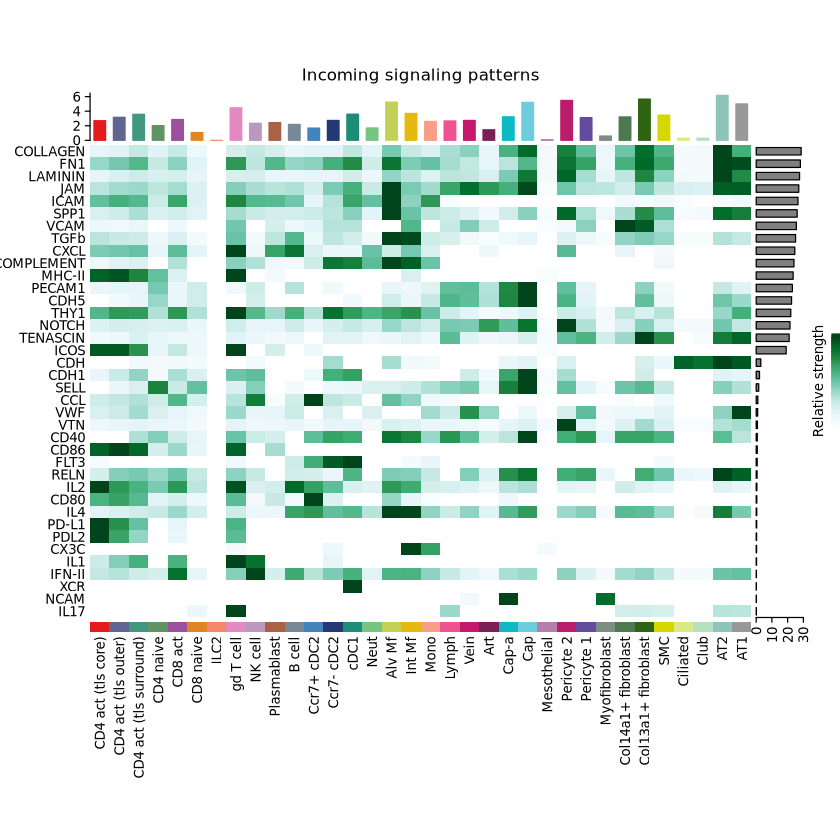

In [118]:
netAnalysis_signalingRole_heatmap(cellchat1, pattern = "incoming", width=14, height = 10)

## Custom plots

1. Create a plot where each row is CD4 tls core, tls outer, or tls surround, and each column is incoming signaling pathway
2. Create a plot where each row is CD4 tls core, tls outer, or tls surround, and each column is the importance of a sender cell type for a selected pathway (or LR interaction)

To make these, make custom version of netAnalysis_signalingRole_heatmap and netAnalysis_signalingRole_network (https://github.com/jinworks/CellChat/blob/main/R/analysis.R)

###  customizing: netAnalysis_signalingRole_heatmap 

In [24]:
#  customizing: netAnalysis_signalingRole_heatmap 

pattern <- "incoming"
slot.name = "netP"
# color.heatmap = "BuGn"
# color.heatmap = "Blues"
color.heatmap = rev("Spectral")
signaling=NULL
title = NULL
color.use = NULL
width = 2
height = 16#20
font.size = 8
font.size.title = 10
cluster.rows = FALSE
cluster.cols = FALSE

# ka add
targets.use = c('CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)')

object = cellchat
centr <- slot(object, slot.name)$centr
outgoing <- matrix(0, nrow = nlevels(object@idents), ncol = length(centr))
incoming <- matrix(0, nrow = nlevels(object@idents), ncol = length(centr))
dimnames(outgoing) <- list(levels(object@idents), names(centr))
dimnames(incoming) <- dimnames(outgoing)

# length of centr is equivalent to the number of signaling pathways 
for (i in 1:length(centr)) {
    outgoing[,i] <- centr[[i]]$outdeg
    incoming[,i] <- centr[[i]]$indeg
  }
# mat is transpose of incoming or outgoing, such that rows are signal pathways, and columns are cell types
  if (pattern == "outgoing") {
    mat <- t(outgoing)
    legend.name <- "Outgoing"
  } else if (pattern == "incoming") {
    mat <- t(incoming)
    legend.name <- "Incoming"
  } else if (pattern == "all") {
    mat <- t(outgoing+ incoming)
    legend.name <- "Overall"
  }
  if (is.null(title)) {
    title <- paste0(legend.name, " signaling patterns")
  } else {
    title <- paste0(paste0(legend.name, " signaling patterns"), " - ",title)
  }

# drop signaling pathway rows not in specified list, if specified 
  if (!is.null(signaling)) {
    mat1 <- mat[rownames(mat) %in% signaling, , drop = FALSE]
    mat <- matrix(0, nrow = length(signaling), ncol = ncol(mat))
    idx <- match(rownames(mat1), signaling)
    mat[idx[!is.na(idx)], ] <- mat1
    dimnames(mat) <- list(signaling, colnames(mat1))
  }

# # KA add: drop receiver cell types not in targets.use -- BEFORE scaling across pathways
# mat.allcells <- mat
# if (!is.null(targets.use)) {
#   mat1 <- mat[, colnames(mat) %in% targets.use, drop = FALSE]
#   mat <- matrix(0, nrow = nrow(mat), ncol = length(targets.use))
#   idx <- match(colnames(mat1), targets.use)
#   mat[, idx[!is.na(idx)]] <- mat1
#   dimnames(mat) <- list(rownames(mat1), targets.use)
# }

# row scale the matrix; rows are signals, so this scales a given signal across all cell types 
  mat.ori <- mat
  mat <- sweep(mat, 1L, apply(mat, 1, max), '/', check.margin = FALSE) # column scaling instead would be: mat <- sweep(mat, 2L, apply(mat, 2, max), '/', check.margin = FALSE)
  mat[mat == 0] <- NA

# KA add: drop receiver cell types not in targets.use -- AFTER scaling across pathways
if (!is.null(targets.use)) {
  mat1 <- mat[, colnames(mat) %in% targets.use, drop = FALSE]
  mat <- matrix(0, nrow = nrow(mat), ncol = length(targets.use))
  idx <- match(colnames(mat1), targets.use)
  mat[, idx[!is.na(idx)]] <- mat1
  dimnames(mat) <- list(rownames(mat1), targets.use)
}

 # KA add: remove signaling pathways that are entirely NA
    keep <- !apply(mat, 1, function(x) all(is.nan(x)))
    mat <- mat[keep, , drop = FALSE]
    # also drop these in the unscaled matrix
    mat.ori <- mat.ori[keep, , drop = FALSE]

if (is.null(color.use)) {
    color.use <- scPalette(length(colnames(mat)))
  }
  color.heatmap.use = grDevices::colorRampPalette((RColorBrewer::brewer.pal(n = 9, name = color.heatmap)))(100)

  df<- data.frame(group = colnames(mat)); rownames(df) <- colnames(mat)
  names(color.use) <- colnames(mat)
  # col_annotation <- HeatmapAnnotation(df = df, col = list(group = color.use),which = "column",
  #                                     show_legend = FALSE, show_annotation_name = FALSE,
  #                                     simple_anno_size = grid::unit(0.2, "cm"))
  # ha2 = HeatmapAnnotation(Strength = anno_barplot(colSums(mat.ori), border = FALSE,gp = gpar(fill = color.use, col=color.use)), show_annotation_name = FALSE)

# for the row annotation of sender strength the incoming signals (before scaling) are summed across all cell types for each pathway 
  pSum <- rowSums(mat.ori)
  pSum.original <- pSum
  # pSum <- -1/log(pSum)
  pSum <- -log(pSum)                
  pSum[is.na(pSum)] <- 0
  idx1 <- which(is.infinite(pSum) | pSum < 0)
  if (length(idx1) > 0) {
    values.assign <- seq(max(pSum)*1.1, max(pSum)*1.5, length.out = length(idx1))
    position <- sort(pSum.original[idx1], index.return = TRUE)$ix
    pSum[idx1] <- values.assign[match(1:length(idx1), position)]
  }

  ha1 = rowAnnotation(Strength = anno_barplot(pSum, border = FALSE), show_annotation_name = FALSE)

  if (min(mat, na.rm = T) == max(mat, na.rm = T)) {
    legend.break <- max(mat, na.rm = T)
  } else {
    legend.break <- c(round(min(mat, na.rm = T), digits = 1), round(max(mat, na.rm = T), digits = 1))
  }

    # KA add: flip axes
    # mat = t(mat)

    # KA add: cluster columns
    mat.clust <- mat
    mat.clust[!is.finite(mat.clust)] <- 0   # replaces NA, NaN, Inf, -Inf
    cluster_rows = hclust(dist(mat.clust, method = "euclidean"), method = "ward.D2")
                   
  ht1 = Heatmap(mat, col = color.heatmap.use, na_col = "white", name = "Relative strength",
                # bottom_annotation = col_annotation, 
                # top_annotation = ha2, 
                # right_annotation = ha1,
                # top_annotation = ha1,
                cluster_rows = cluster_rows,
                # cluster_rows = FALSE,
                cluster_columns = cluster.rows,
                # cluster_columns = cluster_columns,
                column_names_side = "top",
                show_column_dend = FALSE,
                show_row_dend = FALSE,
                row_names_side = "left",row_names_rot = 0,row_names_gp = gpar(fontsize = font.size),column_names_gp = gpar(fontsize = font.size),
                width = unit(width, "cm"), height = unit(height, "cm"),
                column_title = title,column_title_gp = gpar(fontsize = font.size.title),column_names_rot = 90,
                heatmap_legend_param = list(title_gp = gpar(fontsize = 8, fontface = "plain"),title_position = "leftcenter-rot",
                                            border = NA, at = legend.break,
                                            legend_height = unit(20, "mm"),labels_gp = gpar(fontsize = 8),grid_width = unit(2, "mm"))
  )
  #  draw(ht1)

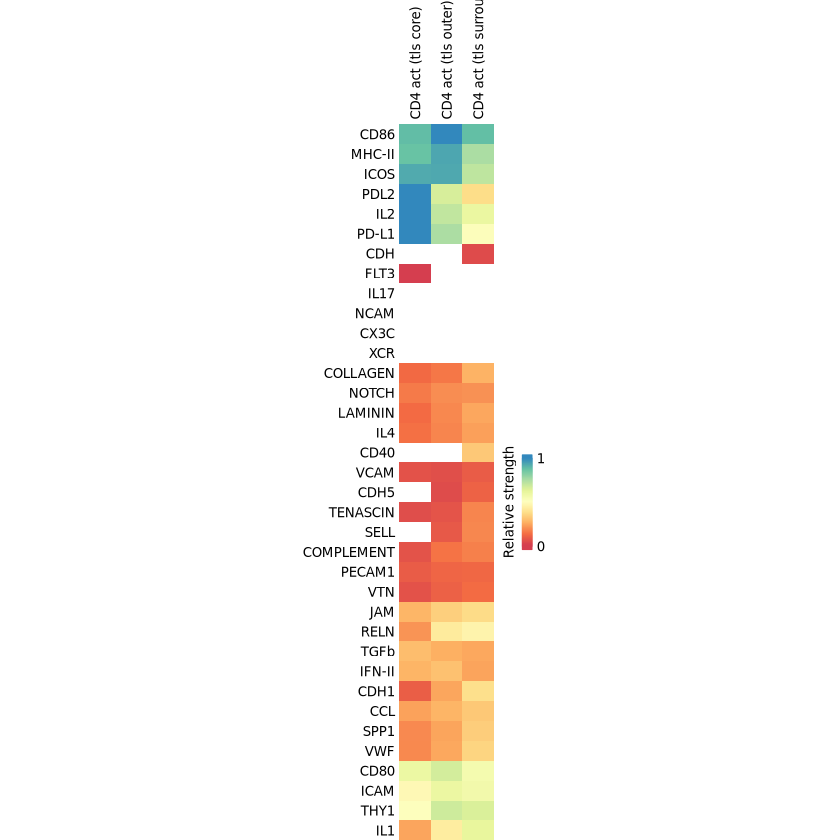

In [25]:
draw(ht1)

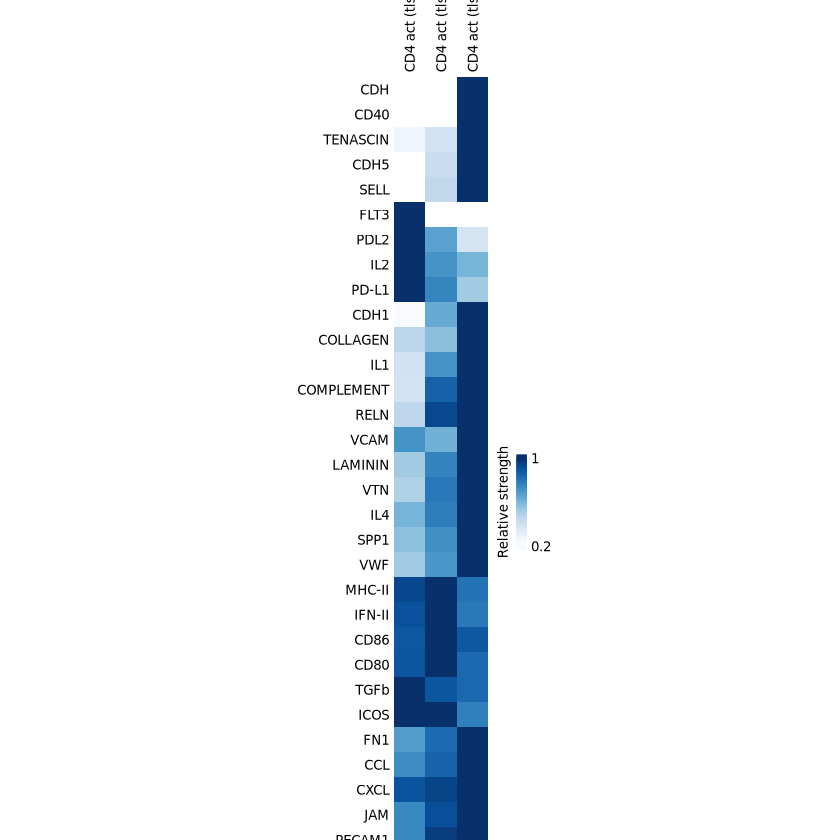

In [12]:
draw(ht1)

png 
  2

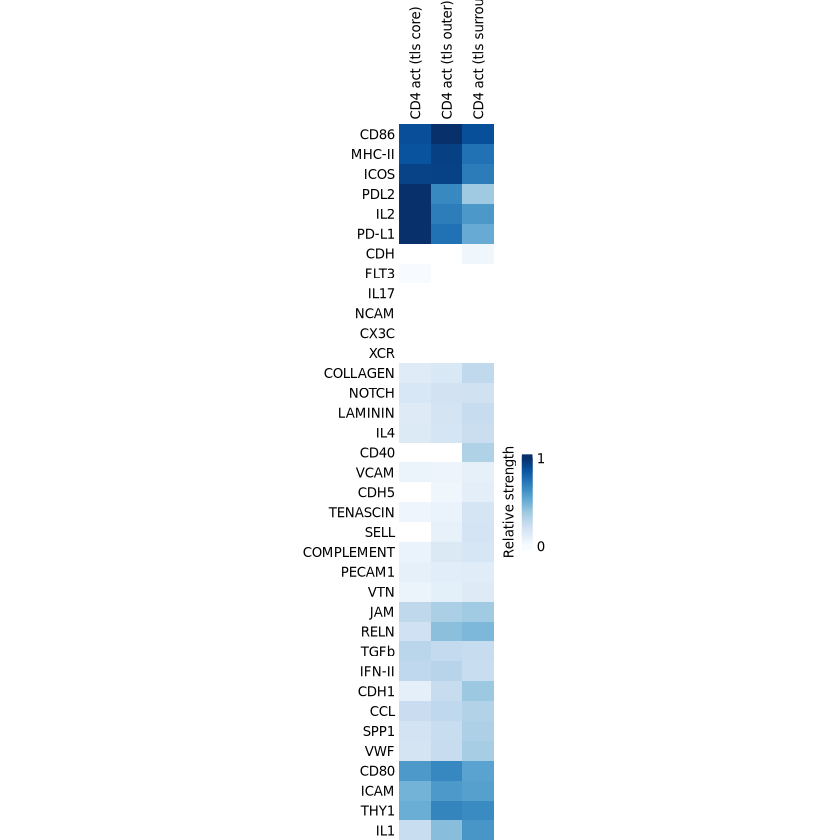

In [21]:
p <- draw(ht1)
pdf(file = file.path(plot_out_dir, "signaling_role_CD4_categories_vertical_scaled-on-all-receivers_clusterrows.pdf"))
p
dev.off()

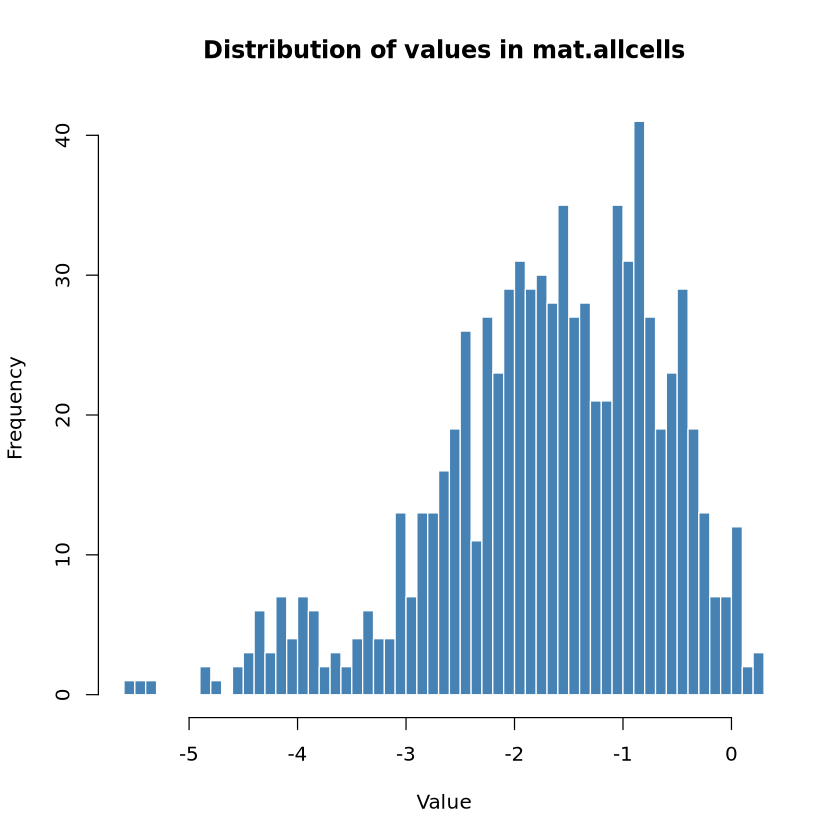

In [14]:
# flatten the matrix to a numeric vector
vals <- as.vector(mat.allcells)

# remove NA/NaN/Inf if present
vals <- log10(vals[is.finite(vals)])

# plot histogram
hist(
  vals,
  breaks = 50,              # number of bins
  main   = "Distribution of values in mat.allcells",
  xlab   = "Value",
  col    = "steelblue",
  border = "white"
)

png 
  2

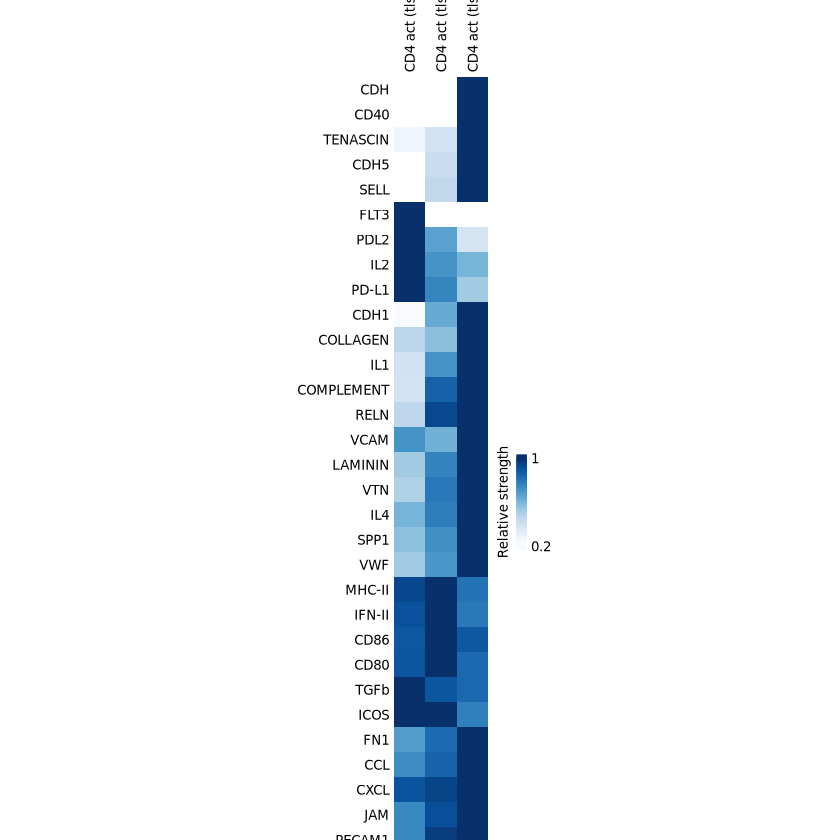

In [15]:
p <- draw(ht1)
pdf(file = file.path(plot_out_dir, "signaling_role_CD4_categories.pdf"))
p
dev.off()

###  customizing: netAnalysis_signalingRole_network to visualize senders 

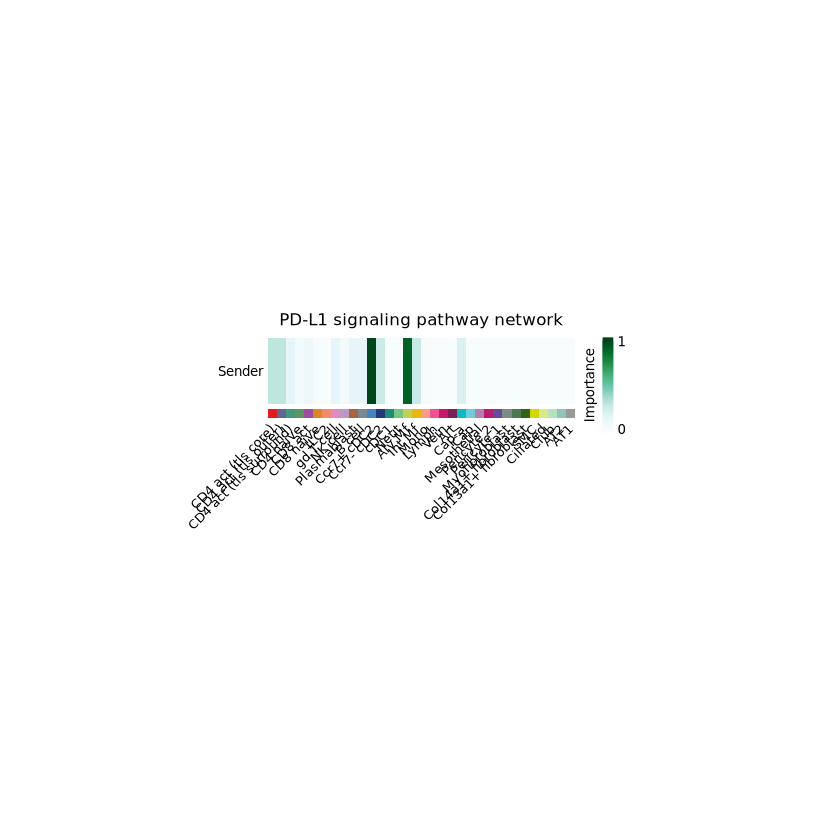

In [16]:
object = cellchat
signaling = "PD-L1"
slot.name = "netP"
measure = c("outdeg")
measure.name = c("Sender")
color.use = NULL
color.heatmap = "BuGn"
width = 6.5
height = 1.4
font.size = 8
font.size.title = 10
cluster.rows = FALSE
cluster.cols = FALSE


centr <- slot(object, slot.name)$centr[signaling]
for(i in 1:length(centr)) {
    centr0 <- centr[[i]]
    mat <- matrix(unlist(centr0), ncol = length(centr0), byrow = FALSE)
    mat <- t(mat)
    rownames(mat) <- names(centr0); colnames(mat) <- names(centr0$outdeg)
    if (!is.null(measure)) {
      mat <- mat[measure,,drop = FALSE]
      if (!is.null(measure.name)) {
        if (length(measure.name) != length(measure)) {
          stop("The length of `measure.name` is not the same as that of `measure`! Please modify it! \n")
        }
        rownames(mat) <- measure.name
      }
    }
    mat <- sweep(mat, 1L, apply(mat, 1, max), '/', check.margin = FALSE)
    
    if (is.null(color.use)) {
      color.use <- scPalette(length(colnames(mat)))
    }
    color.heatmap.use = grDevices::colorRampPalette((RColorBrewer::brewer.pal(n = 9, name = color.heatmap)))(100)
    
    df<- data.frame(group = colnames(mat)); rownames(df) <- colnames(mat)
    cell.cols.assigned <- setNames(color.use, unique(as.character(df$group)))
    col_annotation <- HeatmapAnnotation(df = df, col = list(group = cell.cols.assigned),which = "column",
                                        show_legend = FALSE, show_annotation_name = FALSE,
                                        simple_anno_size = grid::unit(0.2, "cm"))
    
    ht1 = Heatmap(mat, col = color.heatmap.use, na_col = "white", name = "Importance",
                  bottom_annotation = col_annotation,
                  cluster_rows = cluster.rows,cluster_columns = cluster.cols,
                  row_names_side = "left",row_names_rot = 0,row_names_gp = gpar(fontsize = font.size),column_names_gp = gpar(fontsize = font.size),
                  width = unit(width, "cm"), height = unit(height, "cm"),
                  column_title = paste0(names(centr[i]), " signaling pathway network"),column_title_gp = gpar(fontsize = font.size.title),column_names_rot = 45,
                  heatmap_legend_param = list(title = "Importance", title_gp = gpar(fontsize = 8, fontface = "plain"),title_position = "leftcenter-rot",
                                              border = NA, at = c(round(min(mat, na.rm = T), digits = 1), round(max(mat, na.rm = T), digits = 1)),
                                              legend_height = unit(20, "mm"),labels_gp = gpar(fontsize = 8),grid_width = unit(2, "mm"))
    )
    draw(ht1)}

### customizing: netVisual_bubble

In [17]:
netVisual_bubble_targetsOnly <- function(object,
                                         sources.use = NULL,
                                         targets.use = NULL,
                                         signaling = NULL,
                                         thresh = 0.05,
                                         color.heatmap = 'Spectral', # viridis
                                         n.colors = 10,
                                         direction = -1,
                                         font.size = 10,
                                         font.size.title = 10,
                                         show.legend = TRUE,
                                         title.name = NULL,
                                         return.data = FALSE) {
  #--- get communication data
  df.net <- subsetCommunication(object,
                                slot.name = "net",
                                sources.use = sources.use,
                                targets.use = targets.use,
                                signaling = signaling,
                                thresh = thresh)


    df.net.original <- df.net

  #--- filter to only selected targets
  df.net <- df.net[df.net$target %in% targets.use, , drop = FALSE]

  #--- drop nonsignificant
  df.net <- df.net[df.net$pval <= thresh, , drop = FALSE]

  if (nrow(df.net) == 0) stop("No significant interactions found for given targets")

  #--- row labels = sender + interaction
  df.net$row_label <- paste(df.net$source) #df.net$interaction_name_2, sep = " : "

  #--- keep prob + pval for plotting
  df.net$prob[df.net$prob == 0] <- NA
  df.net$prob.original <- df.net$prob
  df.net$prob <- -1 / log(df.net$prob)

  #--- color scale setup (same logic as original function)
  if (length(color.heatmap) == 1) {
    color.use <- tryCatch({
      RColorBrewer::brewer.pal(n = n.colors, name = color.heatmap)
    }, error = function(e) {
      scales::viridis_pal(option = color.heatmap, direction = -1)(n.colors)
    })
  } else {
    color.use <- color.heatmap
  }
  if (direction == -1) {
    color.use <- rev(color.use)
  }

  #--- build ggplot
  g <- ggplot(df.net,
              aes(x = target,
                  y = row_label,
                  color = prob,
                  size = pval)) +
    geom_point(pch = 16) +
    theme_linedraw() +
    theme(panel.grid.major = element_blank(),
          axis.text.x = element_text(angle = 45, hjust = 1),
          axis.title.x = element_blank(),
          axis.title.y = element_blank(),
          text = element_text(size = font.size)) +
    scale_x_discrete(limits = targets.use) +
    ggtitle(title.name)

  #--- continuous color gradient from min to max prob
  min.prob <- min(df.net$prob, na.rm = TRUE)
  max.prob <- max(df.net$prob, na.rm = TRUE)

  g <- g + scale_colour_gradientn(colors = colorRampPalette(color.use)(99),
                                  na.value = "white",
                                  limits = c(min.prob, max.prob),
                                  breaks = c(min.prob, max.prob),
                                  labels = c("min", "max"),
                                  name = "Commun. Prob.")

  if (!show.legend) {
    g <- g + theme(legend.position = "none")
  }

  show(g)
  if (return.data) {
    # return(df.net)
      return(df.net.original)
  } else {
    return(g)
  }
}


In [18]:
library(ComplexHeatmap)
library(RColorBrewer)
library(circlize)

netVisual_heatmap_targetsOnly <- function(object,
                                          sources.use = NULL,
                                          targets.use = NULL,
                                          signaling = NULL,
                                          thresh = 0.05,
                                          # color.heatmap = "Spectral",
                                          color.heatmap = "BuGn",
                                          n.colors = 10,
                                          # direction = -1,
                                          direction = 1,
                                          font.size = 10,
                                          font.size.title = 10,
                                          title.name = NULL,
                                          cluster.rows = FALSE,
                                          cluster.cols = FALSE,
                                          row.order = NULL,
                                          return.data = FALSE) {


    # color setup
  color.heatmap = grDevices::colorRampPalette((RColorBrewer::brewer.pal(n = 9, name = color.heatmap)))(100)
    
  #--- get communication data
  df.net <- subsetCommunication(object,
                                slot.name = "net",
                                sources.use = sources.use,
                                targets.use = targets.use,
                                signaling = signaling,
                                thresh = thresh)

  df.net.original <- df.net

  #--- filter to only selected targets
  df.net <- df.net[df.net$target %in% targets.use, , drop = FALSE]

  #--- drop nonsignificant
  df.net <- df.net[df.net$pval <= thresh, , drop = FALSE]

  if (nrow(df.net) == 0) stop("No significant interactions found for given targets")

  #--- row labels = sender + interaction
  df.net$row_label <- paste(df.net$source)

  #--- keep prob + pval for plotting
  df.net$prob[df.net$prob == 0] <- NA
  df.net$prob.original <- df.net$prob
  df.net$prob <- -1 / log(df.net$prob)

  #--- pivot into wide matrix
  mat <- reshape2::acast(df.net, row_label ~ target, value.var = "prob", fun.aggregate = mean)

  #--- color scale setup
  if (length(color.heatmap) == 1) {
    color.use <- tryCatch({
      RColorBrewer::brewer.pal(n = n.colors, name = color.heatmap)
    }, error = function(e) {
      scales::viridis_pal(option = color.heatmap, direction = -1)(n.colors)
    })
  } else {
    color.use <- color.heatmap
  }
  if (direction == -1) {
    color.use <- rev(color.use)
  }
  color.heatmap.use <- colorRampPalette(color.use)(100)

#--- enforce row order if provided
  if (!is.null(row.order)) {
    row.keep <- intersect(row.order, rownames(mat))
    mat <- mat[row.keep, , drop = FALSE]
  }

  #--- build heatmap
  ht <- Heatmap(mat,
                col = color.heatmap.use,
                na_col = "white",
                name = "Commun. Prob.",
                cluster_rows = cluster.rows, 
                show_row_dend = FALSE,
                cluster_columns=FALSE,
                row_names_gp = grid::gpar(fontsize = font.size),
                column_names_gp = grid::gpar(fontsize = font.size),
                column_title = title.name,
                column_title_gp = grid::gpar(fontsize = font.size.title),
                row_names_side = "left")

  draw(ht)

  if (return.data) {
    return(mat)
  } else {
    return(ht)
  }
}


circlize version 0.4.16
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in published research, please cite:
Gu, Z. circlize implements and enhances circular visualization
  in R. Bioinformatics 2014.

This message can be suppressed by:
  suppressPackageStartupMessages(library(circlize))



Attaching package: ‘circlize’


The following object is masked from ‘package:igraph’:

    degree




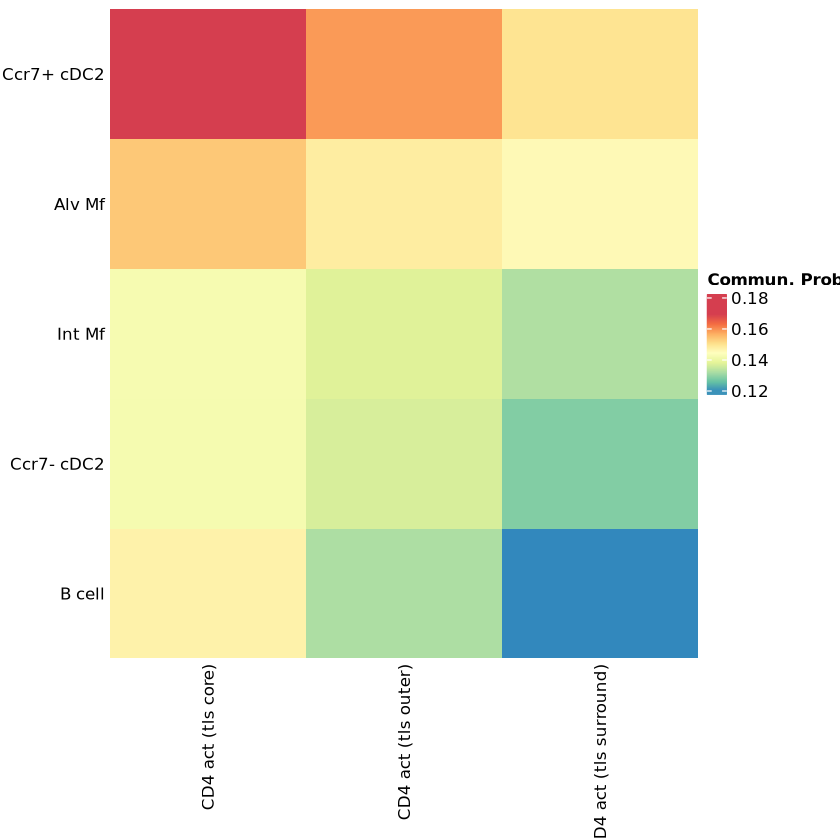

In [19]:
netVisual_heatmap_targetsOnly(cellchat, 
                              color.heatmap = "Spectral",
                              direction = -1,
                                      signaling = c("PDL2"),
                                      sources.use = c('B cell', 'Ccr7+ cDC2', 'Ccr7- cDC2', 'Alv Mf', 'Int Mf'),
                                      targets.use = c('CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)'),
                              cluster.rows = TRUE, 
                              return.data=FALSE)


In [26]:
pdf(file = file.path(plot_out_dir, "PDL2_senders_CD4_categories.pdf"), width=4, height=5)
netVisual_heatmap_targetsOnly(cellchat, 
                              # color.heatmap = "Spectral",
                              # direction = -1,
                              color.heatmap = "Blues",
                              direction = 1,
                                      signaling = c("PDL2"),
                                      sources.use = c('B cell', 'Ccr7+ cDC2', 'Ccr7- cDC2', 'Alv Mf', 'Int Mf'),
                                      targets.use = c('CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)'),
                              cluster.rows = FALSE, 
                              row.order = c('Ccr7+ cDC2', 'Alv Mf', 'Int Mf','Ccr7- cDC2', 'B cell' ),
                              return.data=FALSE)
dev.off()

png 
  2

In [27]:
pdf(file = file.path(plot_out_dir, "PDL1_senders_CD4_categories.pdf"), width=4, height=5)
netVisual_heatmap_targetsOnly(cellchat, 
                              # color.heatmap = "Spectral",
                              # direction = -1,
                              color.heatmap = "Blues",
                              direction = 1,
                                      signaling = c("PD-L1"),
                                      sources.use = c('B cell', 'Ccr7+ cDC2', 'Ccr7- cDC2', 'Alv Mf', 'Int Mf'),
                                      targets.use = c('CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)'),
                              cluster.rows = FALSE, 
                              row.order = c('Ccr7+ cDC2', 'Alv Mf', 'Int Mf','Ccr7- cDC2', 'B cell' ),
                              return.data=FALSE)
dev.off()

png 
  2

In [29]:
pdf(file = file.path(plot_out_dir, "PDL2_senders_CD4_categories_dots.pdf"), width=4, height=5)

options(repr.plot.width =4 , repr.plot.height = 6)
df.net = netVisual_bubble_targetsOnly(cellchat, 
                                      signaling = c("PDL2"),
                                      sources.use = c('B cell', 'Ccr7+ cDC2', 'Ccr7- cDC2', 'Alv Mf', 'Int Mf'),
                                      targets.use = c('CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)'),
                                      return.data=TRUE)

dev.off()


png 
  2

In [30]:
pdf(file = file.path(plot_out_dir, "PDL1_senders_CD4_categories_dots.pdf"), width=4, height=5)

options(repr.plot.width = 1, repr.plot.height = 6)
df.net = netVisual_bubble_targetsOnly(cellchat, 
                                      signaling = c("PD-L1"),
                                      sources.use = c('B cell', 'Ccr7+ cDC2', 'Ccr7- cDC2', 'Alv Mf', 'Int Mf'),
                                      targets.use = c('CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)'),
                                      return.data=TRUE)

dev.off()

png 
  2

Comparing communications on a single object 




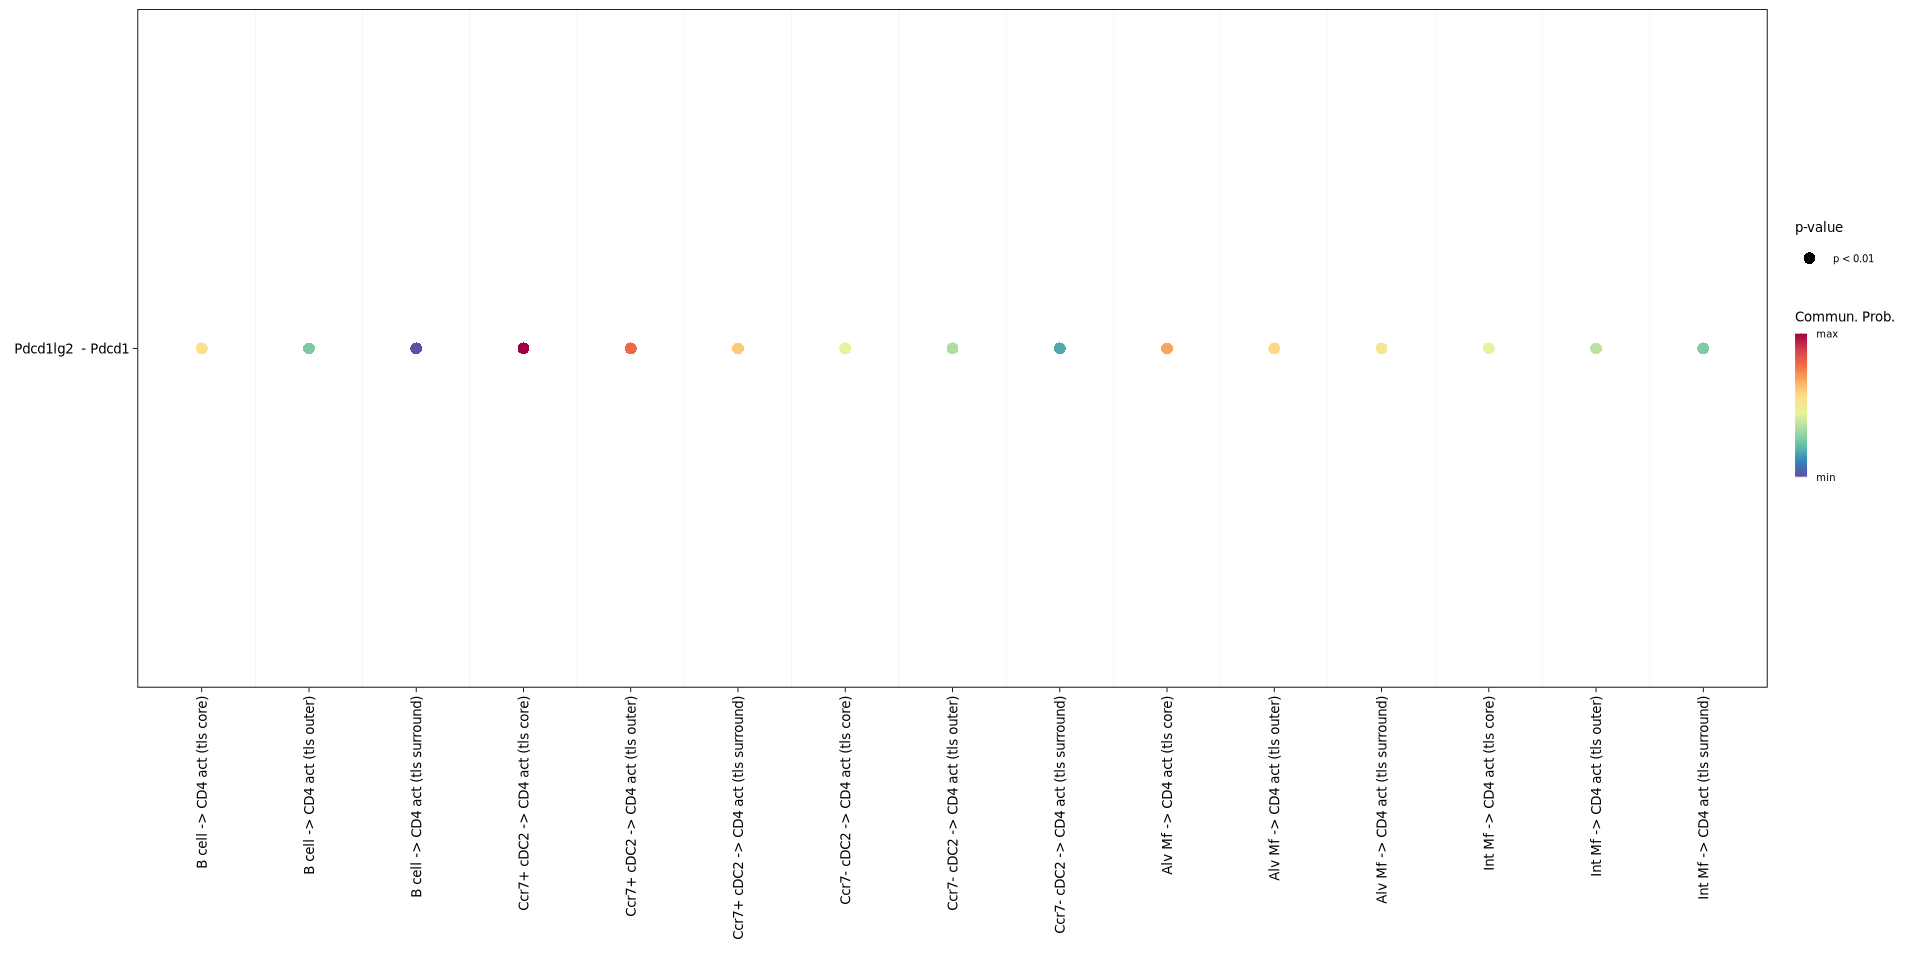

In [31]:
# check with original
options(repr.plot.width = 16, repr.plot.height = 8)
netVisual_bubble(
  cellchat,
  sources.use = c('B cell', 'Ccr7+ cDC2', 'Ccr7- cDC2', 'Alv Mf', 'Int Mf'),
  targets.use = c('CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)'),
  signaling = c("PDL2"),  
    # pairLR.use = pairLR.use,
    remove.isolate = TRUE, 
)

Comparing communications on a single object 




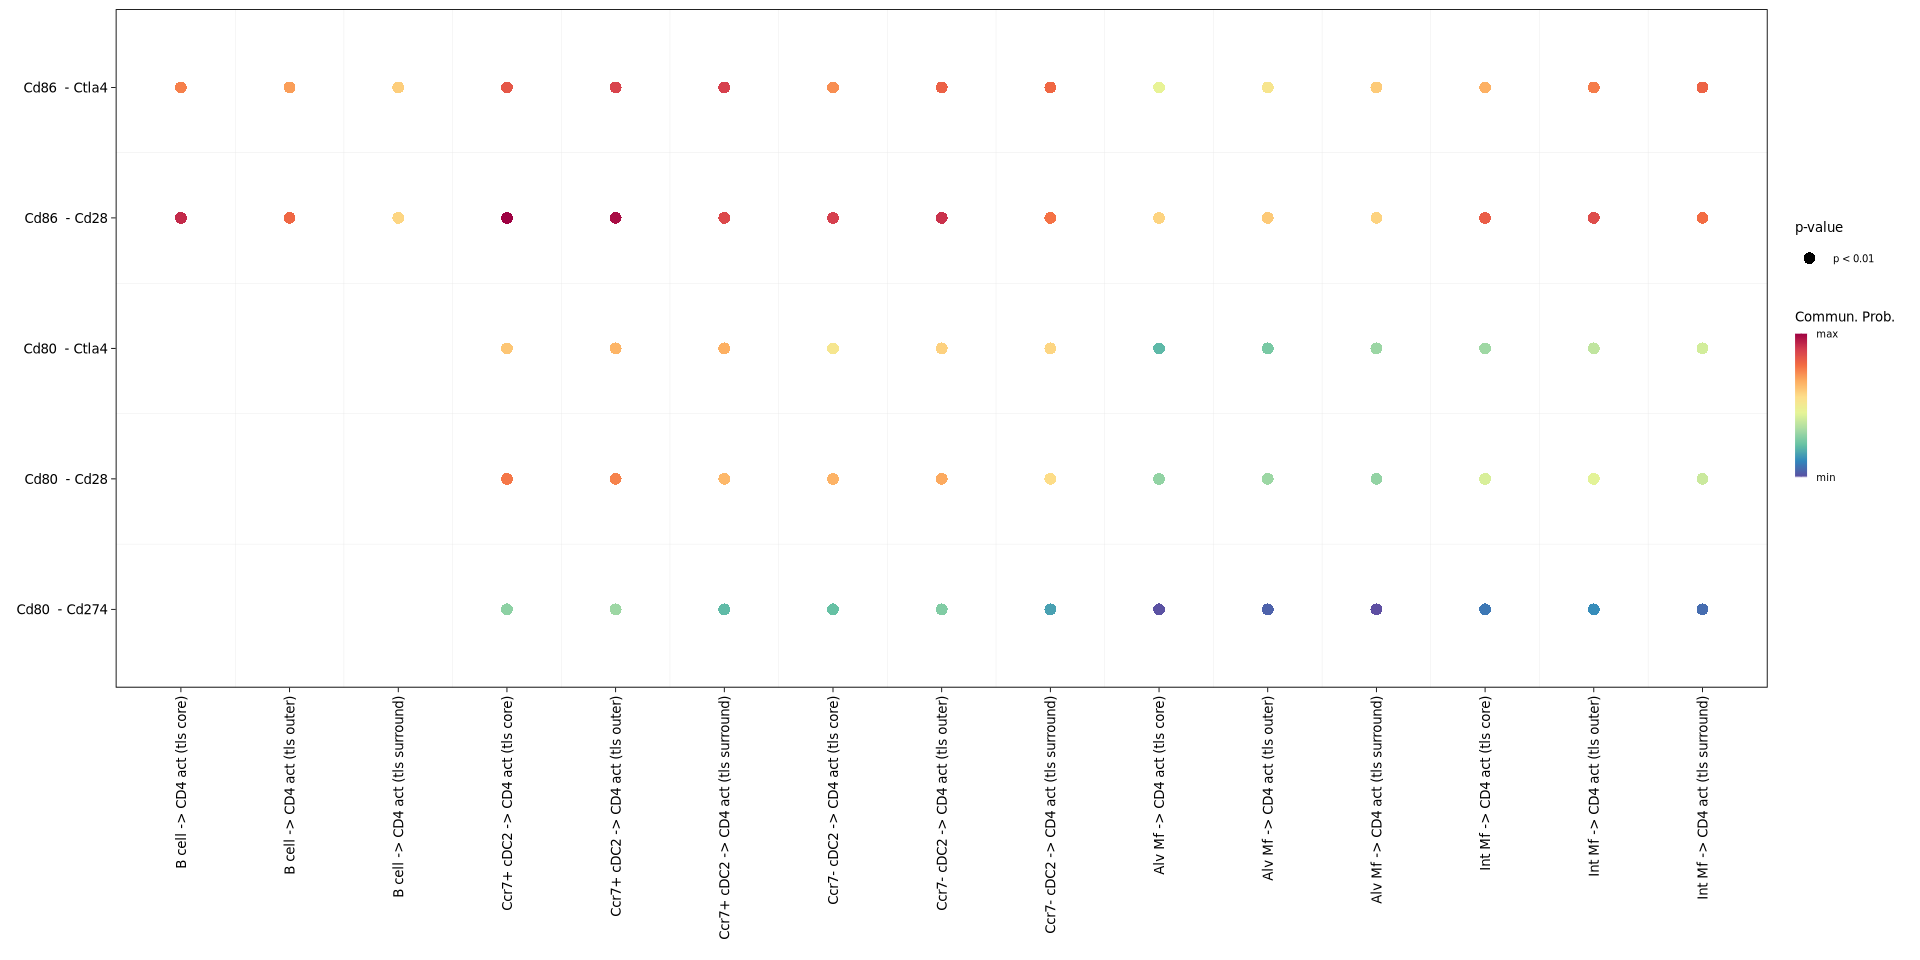

In [30]:
# check with original
options(repr.plot.width = 16, repr.plot.height = 8)
netVisual_bubble(
  cellchat,
  sources.use = c('B cell', 'Ccr7+ cDC2', 'Ccr7- cDC2', 'Alv Mf', 'Int Mf'),
  targets.use = c('CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)'),
  signaling = c("CD80","CD86"),  
    # pairLR.use = pairLR.use,
    remove.isolate = TRUE, 
)

## Cellchat plots 

In [29]:
# p <- netAnalysis_signalingRole_heatmap(cellchat, pattern = "incoming", signaling= "PD-L1", width=14, height = 10)
# p

In [40]:
pdf(file = file.path(plot_out_dir, "incoming_signals_allcells.pdf"))
netAnalysis_signalingRole_heatmap(cellchat, pattern = "incoming", color.heatmap = "Blues", color.use=celltype_palette_mapped)
dev.off()

png 
  2

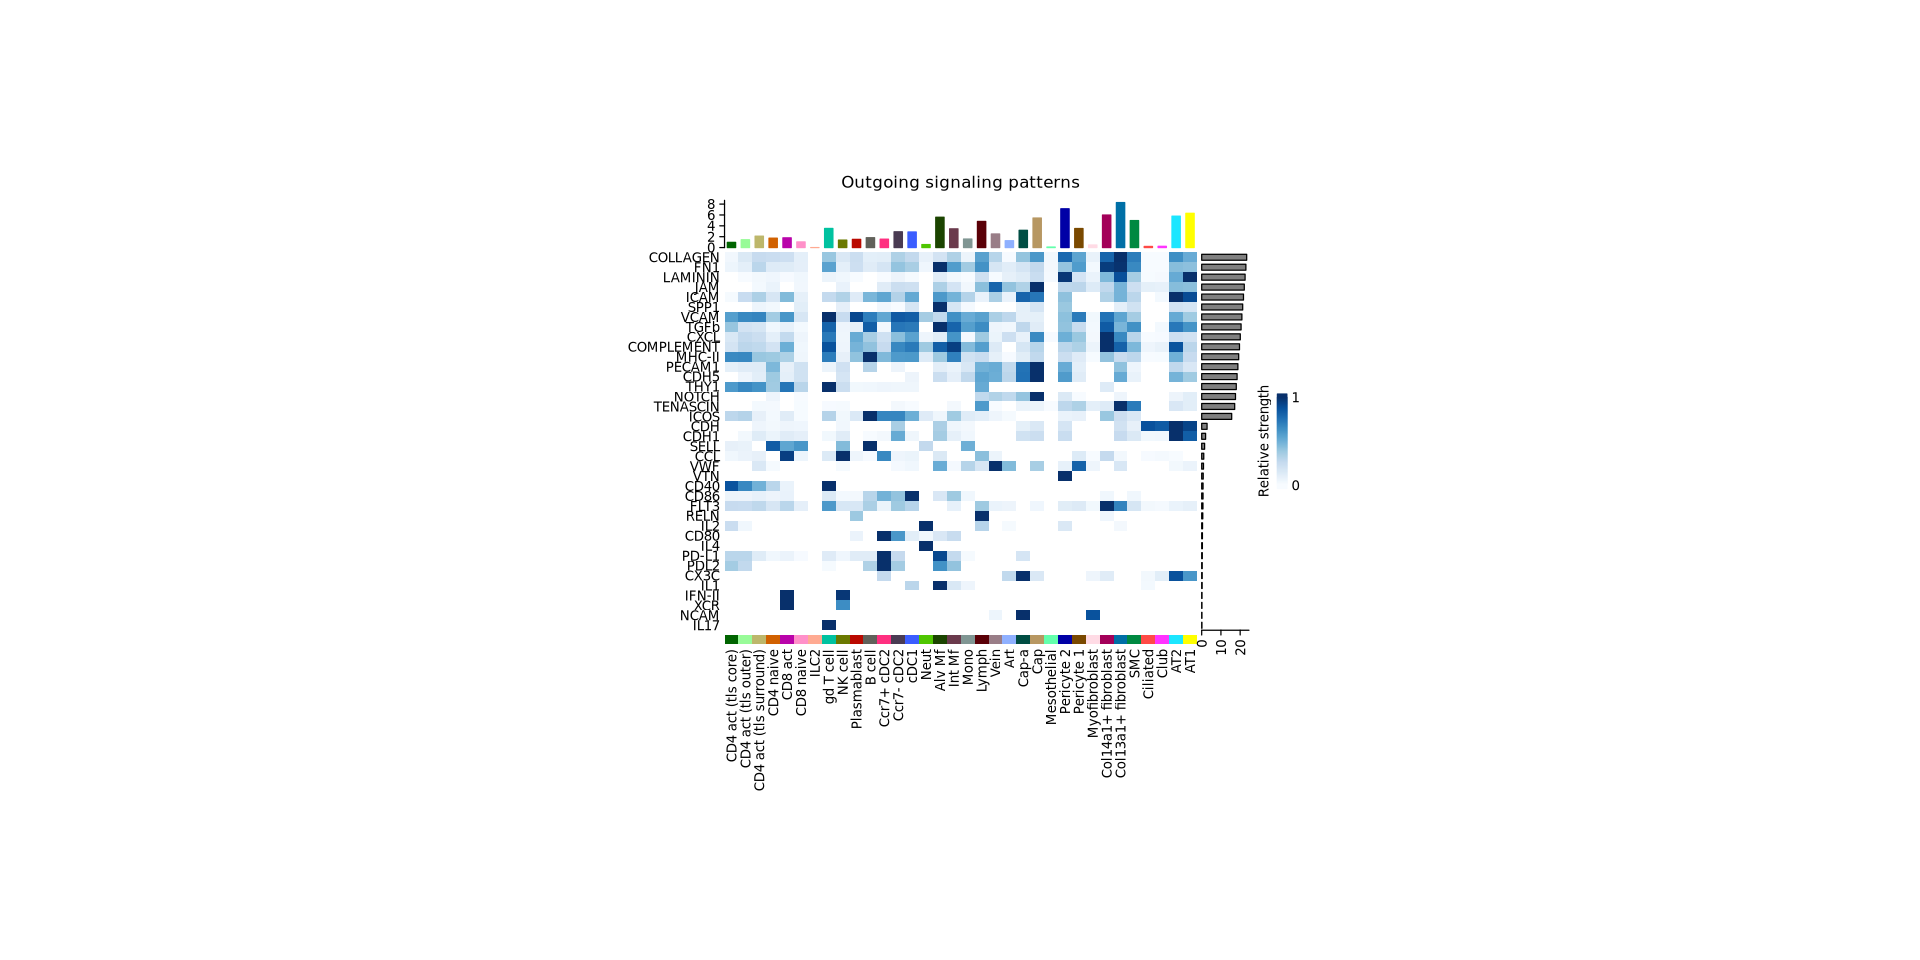

In [39]:
netAnalysis_signalingRole_heatmap(cellchat, pattern = "outgoing", color.heatmap = "Blues", color.use=celltype_palette_mapped)

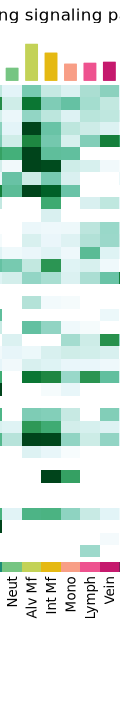

In [53]:
p <- netAnalysis_signalingRole_heatmap(cellchat, pattern = "incoming", width=14, height = 10)
# pdf(file = file.path(plot_out_dir, "signaling_role_populationsize_FALSE.pdf"))
p
# dev.off()

In [11]:
p <- netAnalysis_signalingRole_heatmap(cellchat, pattern = "incoming", width=14, height = 10)
pdf(file = file.path(plot_out_dir, "signaling_role_populationsize_FALSE.pdf"))
p
dev.off()

png 
  2

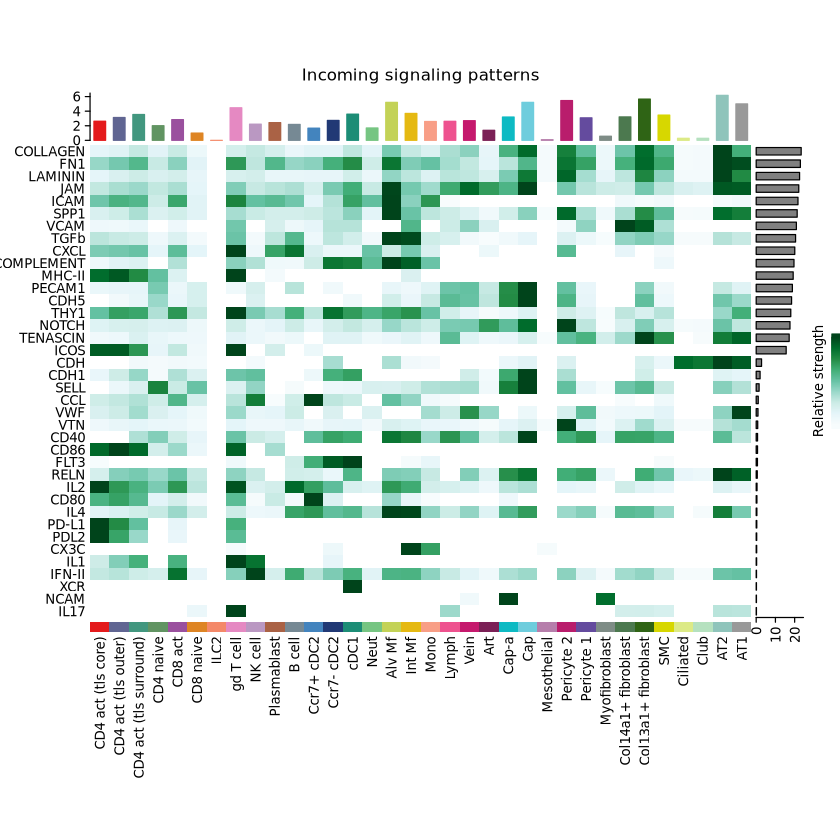

In [12]:
p

In [ ]:
pathways.show <- c("PDL2")


pdf(file = file.path(plot_out_dir, paste0(pathways.show[1], "_signaling_role.pdf")))
netAnalysis_signalingRole_network(cellchat, signaling = pathways.show,
                                  measure = c("outdeg", "indeg"), measure.name = c("Sender", "Receiver"), # exclude , "Mediator", "Influencer"
                                  width = 14, height = 4, font.size = 10)
dev.off()


In [ ]:
pathways.show <- c("PD-L1")


pdf(file = file.path(plot_out_dir, paste0(pathways.show[1], "_signaling_role.pdf")))
netAnalysis_signalingRole_network(cellchat, signaling = pathways.show,
                                  measure = c("outdeg", "indeg"), measure.name = c("Sender", "Receiver"), # exclude , "Mediator", "Influencer"
                                  width = 14, height = 4, font.size = 10)
dev.off()


In [26]:
pathways.show <- c("MHC-II")


pdf(file = file.path(plot_out_dir, paste0(pathways.show[1], "_signaling_role.pdf")))
netAnalysis_signalingRole_network(cellchat, signaling = pathways.show,
                                  measure = c("outdeg", "indeg"), measure.name = c("Sender", "Receiver"), # exclude , "Mediator", "Influencer"
                                  width = 14, height = 4, font.size = 10)
dev.off()


png 
  2

In [ ]:
pathways.show <- c("ICOS")


pdf(file = file.path(plot_out_dir, paste0(pathways.show[1], "_signaling_role.pdf")))
netAnalysis_signalingRole_network(cellchat, signaling = pathways.show,
                                  measure = c("outdeg", "indeg"), measure.name = c("Sender", "Receiver"), # exclude , "Mediator", "Influencer"
                                  width = 14, height = 4, font.size = 10)
dev.off()


In [ ]:
pathways.show <- c("CD80")


pdf(file = file.path(plot_out_dir, paste0(pathways.show[1], "_signaling_role.pdf")))
netAnalysis_signalingRole_network(cellchat, signaling = pathways.show,
                                  measure = c("outdeg", "indeg"), measure.name = c("Sender", "Receiver"), # exclude , "Mediator", "Influencer"
                                  width = 14, height = 4, font.size = 10)
dev.off()


In [ ]:
pathways.show <- c("CD86")


pdf(file = file.path(plot_out_dir, paste0(pathways.show[1], "_signaling_role.pdf")))
netAnalysis_signalingRole_network(cellchat, signaling = pathways.show,
                                  measure = c("outdeg", "indeg"), measure.name = c("Sender", "Receiver"), # exclude , "Mediator", "Influencer"
                                  width = 14, height = 4, font.size = 10)
dev.off()


In [ ]:
pathways.show <- c("FN1")


pdf(file = file.path(plot_out_dir, paste0(pathways.show[1], "_signaling_role.pdf")))
netAnalysis_signalingRole_network(cellchat, signaling = pathways.show,
                                  measure = c("outdeg", "indeg"), measure.name = c("Sender", "Receiver"), # exclude , "Mediator", "Influencer"
                                  width = 14, height = 4, font.size = 10)
dev.off()


In [ ]:

pathways.show <- c("IL1")


pdf(file = file.path(plot_out_dir, paste0(pathways.show[1], "_signaling_role.pdf")))
netAnalysis_signalingRole_network(cellchat, signaling = pathways.show,
                                  measure = c("outdeg", "indeg"), measure.name = c("Sender", "Receiver"), # exclude , "Mediator", "Influencer"
                                  width = 14, height = 4, font.size = 10)
dev.off()


In [ ]:
pathways.show <- c("PD-L1")
netAnalysis_signalingRole_network(cellchat, signaling = pathways.show,
                                  measure = c("outdeg", "indeg"), measure.name = c("Sender", "Receiver"), # exclude , "Mediator", "Influencer"
                                  width = 14, height = 4, font.size = 10)

### Circle plots

In [293]:
celltype_palette_mapped

AT1                    AT2                   Club 
             "#ffff00"              "#1ce6ff"              "#ff34ff" 
              Ciliated                    SMC    Col13a1+ fibroblast 
             "#ff4a46"              "#008941"              "#006fa6" 
   Col14a1+ fibroblast          Myofibroblast             Pericyte 1 
             "#a30059"              "#ffdbe5"              "#7a4900" 
            Pericyte 2            Mesothelial                    Cap 
             "#0000a6"              "#63ffac"              "#b79762" 
                 Cap-a                    Art                   Vein 
             "#004d43"              "#8fb0ff"              "#997d87" 
                 Lymph                   Mono                 Int Mf 
             "#5a0007"              "#809693"              "#6a3a4c" 
                Alv Mf                   Neut                   cDC1 
             "#1b4400"              "#4fc601"              "#3b5dff" 
            Ccr7- cDC2             Ccr7+ cDC2                 B cell 
             "#4a3b53"              "#ff2f80"              "#61615a" 
           Plasmablast                NK cell              gd T cell 
             "#ba0900"              "#6b7900"              "#00c2a0" 
                  ILC2              CD8 naive              CD4 naive 
             "#ffaa92"              "#ff90c9"              "#d16100" 
    CD4 act (tls core)    CD4 act (tls outer) CD4 act (tls surround) 
             "#006400"              "#98FB98"              "#BDB76B"

In [144]:
pathways.show <- c("PD-L1")

pdf(file = file.path(plot_out_dir, paste0(pathways.show[1], "_circle_plot.pdf")))
p<-netVisual_aggregate(cellchat, signaling = pathways.show, 
                    targets.use = c('CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)'),
                    layout = "circle", color.use=celltype_palette_mapped)
dev.off()


png 
  2

In [145]:
pathways.show <- c("PDL2")

pdf(file = file.path(plot_out_dir, paste0(pathways.show[1], "_circle_plot.pdf")))
p<-netVisual_aggregate(cellchat, signaling = pathways.show, 
                    targets.use = c('CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)'),
                    layout = "circle", color.use=celltype_palette_mapped)
dev.off()


png 
  2

In [100]:
pathways.show <- c("FLT3")

pdf(file = file.path(plot_out_dir, paste0(pathways.show[1], "_circle_plot.pdf")))
p<-netVisual_aggregate(cellchat, signaling = pathways.show, 
                    targets.use = c('CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)'),
                    layout = "circle")
dev.off()

png 
  2

In [28]:
pathways.show <- c("CD80")

pdf(file = file.path(plot_out_dir, paste0(pathways.show[1], "_circle_plot.pdf")))
p<-netVisual_aggregate(cellchat, signaling = pathways.show, 
                    targets.use = c('CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)'),
                    layout = "circle")
dev.off()

png 
  2

In [29]:
pathways.show <- c("CD86")

pdf(file = file.path(plot_out_dir, paste0(pathways.show[1], "_circle_plot.pdf")))
p<-netVisual_aggregate(cellchat, signaling = pathways.show, 
                    targets.use = c('CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)'),
                    layout = "circle")
dev.off()

png 
  2

In [ ]:
pathways.show <- c("ICOS")

pdf(file = file.path(plot_out_dir, paste0(pathways.show[1], "_circle_plot.pdf")))
p<-netVisual_aggregate(cellchat, signaling = pathways.show, 
                    targets.use = c('CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)'),
                    layout = "circle")
dev.off()

In [27]:
pathways.show <- c("MHC-II")

pdf(file = file.path(plot_out_dir, paste0(pathways.show[1], "_circle_plot.pdf")))
p<-netVisual_aggregate(cellchat, signaling = pathways.show, 
                    targets.use = c('CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)'),
                    layout = "circle")
dev.off()

png 
  2

In [ ]:
options(repr.plot.width = 16, repr.plot.height = 8)
netVisual_bubble(
  cellchat,
  # sources.use = sources,
  targets.use = c('CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)'),
  signaling = "PD-L1",  
    # pairLR.use = pairLR.use,
    remove.isolate = TRUE, 
)

Comparing communications on a single object 




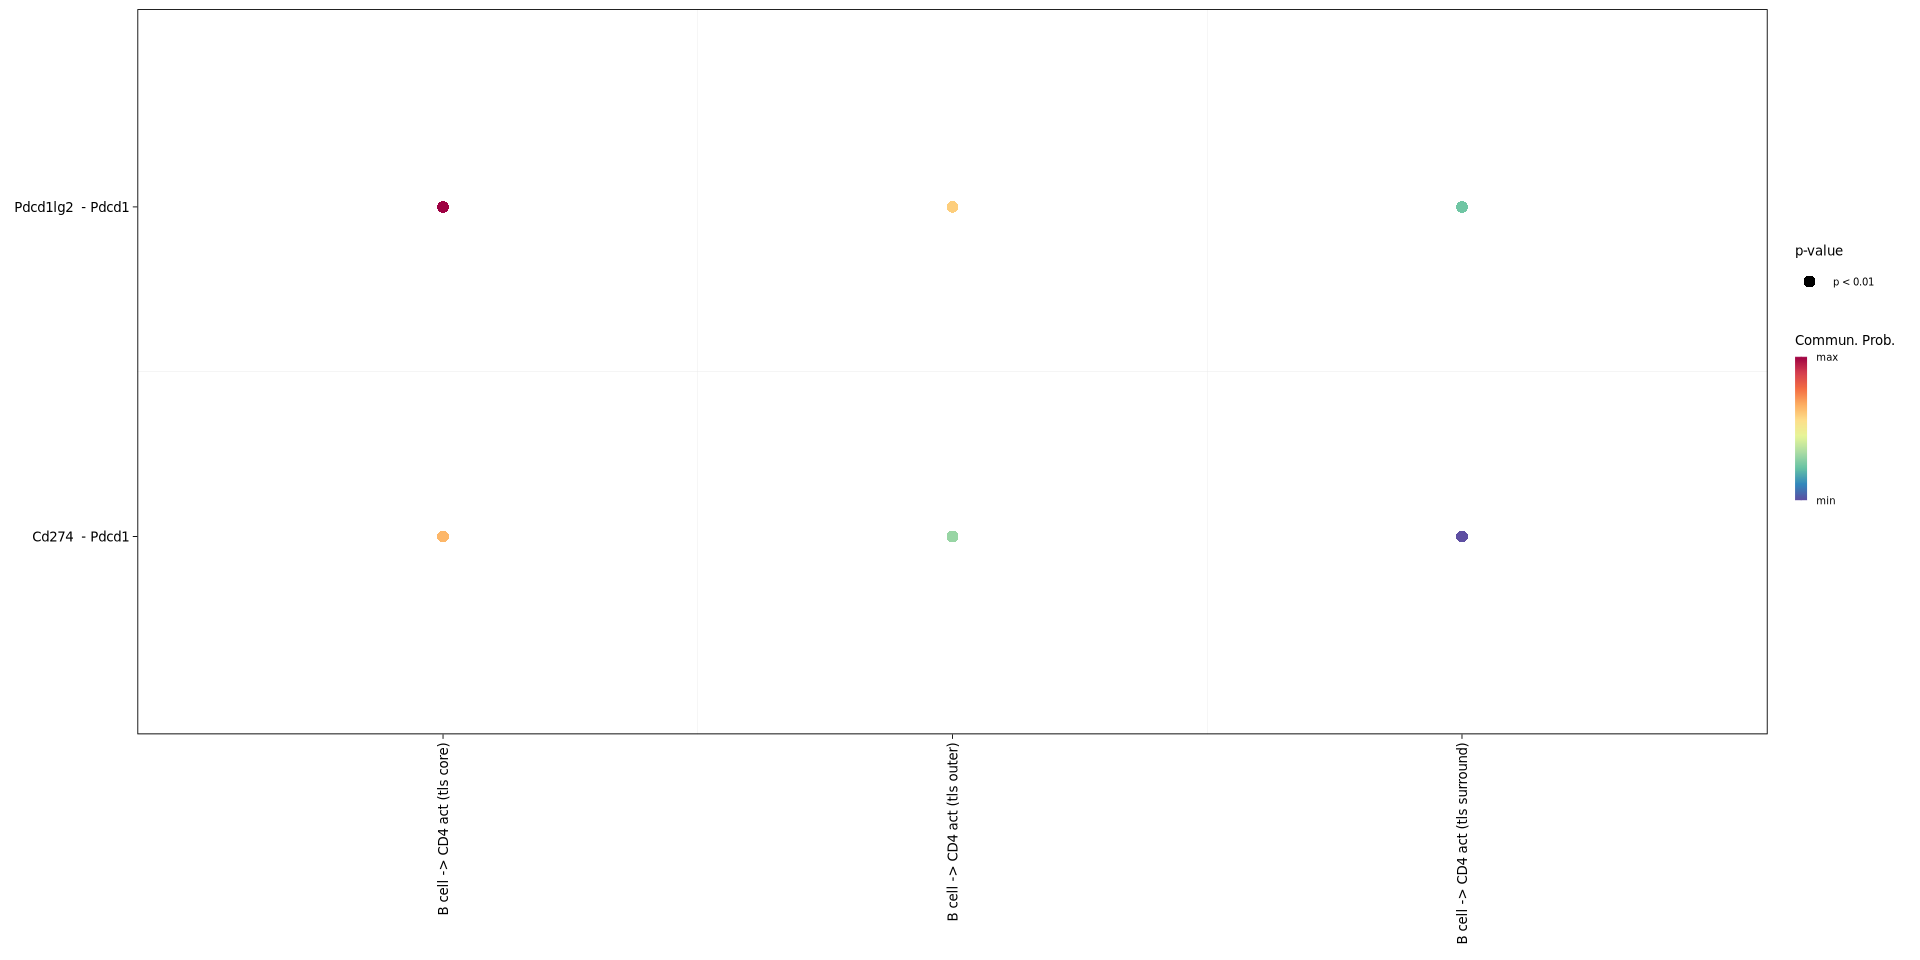

In [145]:
options(repr.plot.width = 16, repr.plot.height = 8)
netVisual_bubble(
  cellchat,
  sources.use = c("B cell"),
  targets.use = c('CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)'),
  signaling = c("PD-L1", "PDL2"),  
    # pairLR.use = pairLR.use,
    remove.isolate = TRUE, 
)